In [2]:
import shap
import numpy as np
import pandas as pd 
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import sys
sys.path.append('/home/student/HallucinationsLLM')
from utils import train_and_eval
from functools import partial
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, precision_recall_fscore_support

[nltk_data] Downloading package punkt to /home/student/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.read_pickle("/home/student/HallucinationsLLM/data/sentences_df_all_features.pkl")

In [11]:
df.columns

Index(['image_link', 'description', 'hallucinations', 'logits', 'objects_num',
       'words_logits_mapping', 'sentence', 'sentence_normalized_index',
       'sentences_labels', 'sentence_contains_hedges', 'sentence_POS',
       'sentence_probes', 'sentence_entropy', 'mean_b', 'mean_g', 'mean_r',
       'mean_rbg', 'image_embedding', 'sentence_len', 'median_sentence_probes',
       'min_sentence_probes', 'max_sentence_probes', 'mean_sentence_probes',
       'median_sentence_entropy', 'min_sentence_entropy',
       'max_sentence_entropy', 'mean_sentence_entropy', 'min_pos_prob',
       'mean_pos_prob', 'max_pos_prob', 'median_pos_prob',
       'sentence_embedding', 'sentence_image_similarity', 'sentence_vec_dim_1',
       'sentence_vec_dim_2', 'sentence_vec_dim_3', 'sentence_vec_dim_4',
       'sentence_vec_dim_5', 'sentence_vec_dim_6', 'sentence_vec_dim_7',
       'sentence_vec_dim_8', 'sentence_vec_dim_9', 'sentence_vec_dim_10',
       'image_vec_dim_1', 'image_vec_dim_2', 'image_vec_

In [14]:
df['sentence'].iloc[0]

' The image depicts a lively street scene with colorful buildings and overhead lights creating a vibrant atmosphere'

In [16]:
df['sentence_probes'].iloc[0]

[0.9288,
 0.7334,
 0.3351,
 0.9803,
 0.2646,
 0.4675,
 0.5215,
 0.2648,
 0.0053,
 0.3395,
 0.4112,
 0.007,
 0.5928,
 0.0858,
 0.8212,
 0.3559,
 0.8572]

In [17]:
FEATURES = ['objects_num', 'sentence_normalized_index',
             'sentence_contains_hedges', 
            'mean_b', 'mean_g', 'mean_r',
            'mean_rbg', 'sentence_len', 'median_sentence_probes',
            'min_sentence_probes', 'max_sentence_probes', 'mean_sentence_probes',
            'median_sentence_entropy', 'min_sentence_entropy',
            'max_sentence_entropy', 'mean_sentence_entropy', 'min_pos_prob',
            'mean_pos_prob', 'max_pos_prob', 'median_pos_prob',
            'sentence_image_similarity', 'sentence_vec_dim_1',
            'sentence_vec_dim_2', 'sentence_vec_dim_3', 'sentence_vec_dim_4',
            'sentence_vec_dim_5', 'sentence_vec_dim_6', 'sentence_vec_dim_7',
            'sentence_vec_dim_8', 'sentence_vec_dim_9', 'sentence_vec_dim_10',
            'image_vec_dim_1', 'image_vec_dim_2', 'image_vec_dim_3',
            'image_vec_dim_4', 'image_vec_dim_5', 'image_vec_dim_6',
            'image_vec_dim_7', 'image_vec_dim_8', 'image_vec_dim_9',
            'image_vec_dim_10', 'contains_CD', 'contains_NNS', 'contains_JJR']

LABEL = 'sentences_labels'

In [18]:
xgb_model_class = partial(XGBClassifier, n_estimators=200, max_depth=50, eta=0.05, gamma=0.1, reg_lambda=0.8, min_child_weight=2, random_state=42)
xgb_model, data_split, results = train_and_eval(df, xgb_model_class, FEATURES, LABEL)

In [19]:
results

{'accuracy': 0.6209150326797386,
 'precision': 0.6234087481146305,
 'recall': 0.6209150326797386,
 'f1_score': 0.6212066365007541,
 'ROC_AUC': 0.6712962962962963}

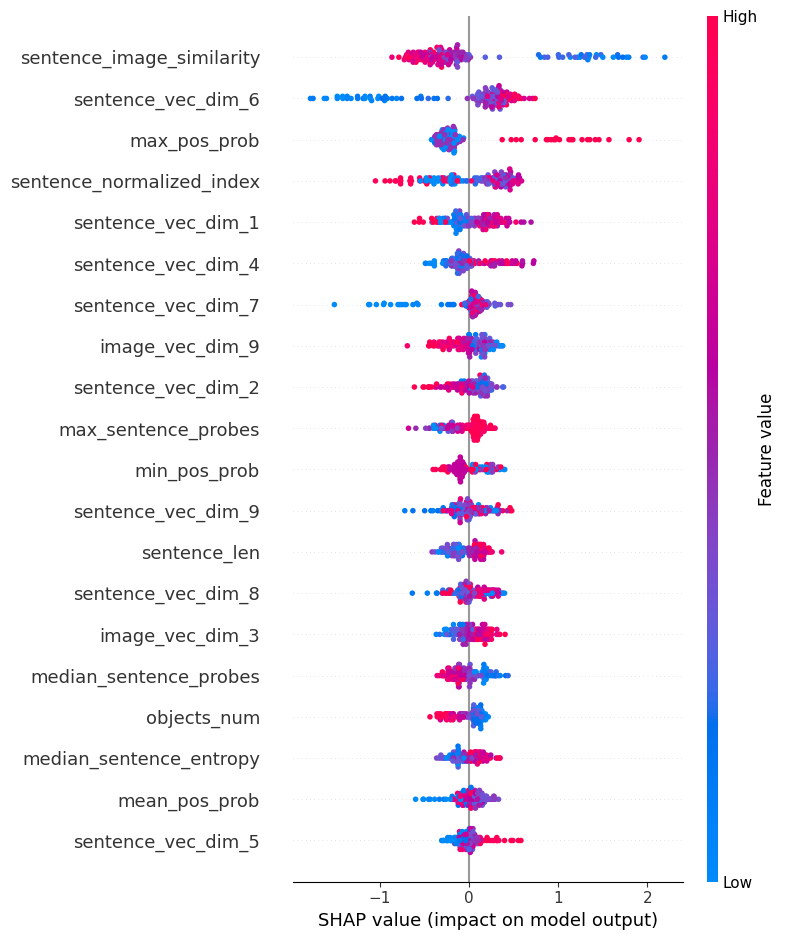

In [20]:
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
X_test = data_split['x_test']
xgb_shap_values = explainer.shap_values(X_test)
shap.summary_plot(xgb_shap_values, X_test, feature_names=X_test.columns)

In [21]:
xgb_feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean SHAP Value': [np.mean(np.abs(xgb_shap_values.T[i]), axis=0) for i in range(len(xgb_shap_values.T))]
}).sort_values(by='Mean SHAP Value', ascending=False)

xgb_feature_importance

,Feature,Mean SHAP Value
20,sentence_image_similarity,0.556876
26,sentence_vec_dim_6,0.483331
18,max_pos_prob,0.368718
1,sentence_normalized_index,0.358238
21,sentence_vec_dim_1,0.213696
24,sentence_vec_dim_4,0.198630
27,sentence_vec_dim_7,0.177710
39,image_vec_dim_9,0.161943
22,sentence_vec_dim_2,0.156106
10,max_sentence_probes,0.155472


In [33]:
rf_model_class = partial(RandomForestClassifier, n_estimators=200, max_depth=50,min_samples_split=2, random_state=42)
rf_model, data_split, rf_results = train_and_eval(df, rf_model_class, FEATURES, LABEL)
rf_results

{'accuracy': 0.5882352941176471,
 'precision': 0.5867235705470999,
 'recall': 0.5882352941176471,
 'f1_score': 0.5862434292595802,
 'ROC_AUC': 0.6619513031550068}

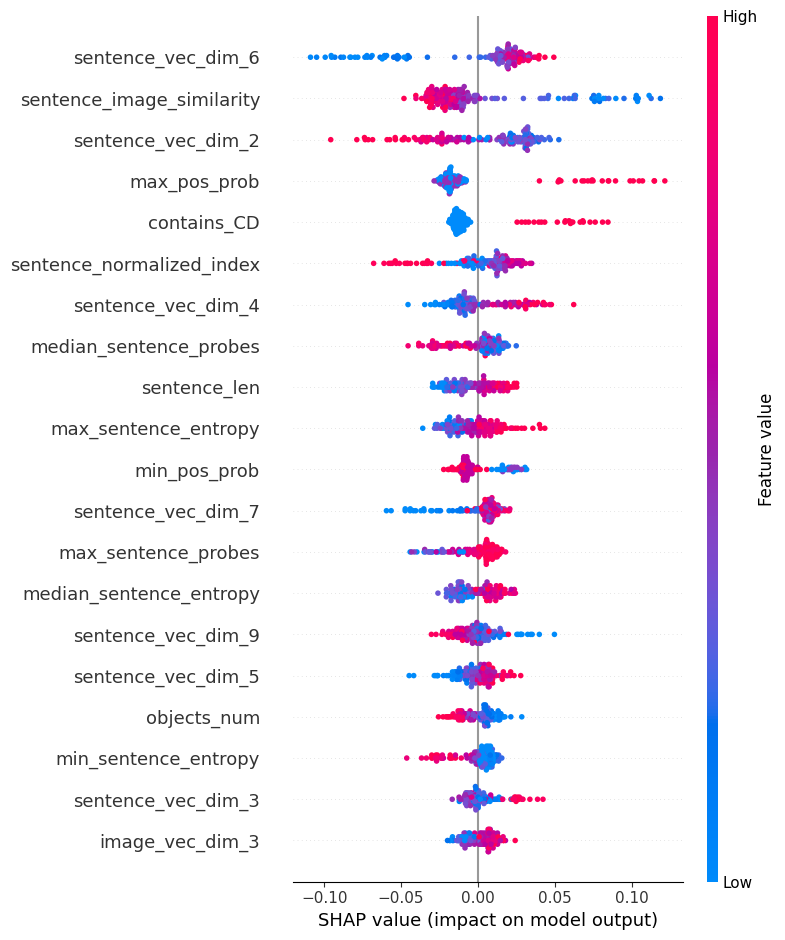

In [53]:
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
X_test = data_split['x_test']
rf_shap_values = explainer.shap_values(X_test)
shap.summary_plot(rf_shap_values[:, :, 1], X_test, feature_names=X_test.columns)

In [51]:
rf_feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean SHAP Value': [np.mean(np.abs(rf_shap_values[:, :, 1].T[i]), axis=0) for i in range(len(rf_shap_values[:, :, 1].T))]
}).sort_values(by='Mean SHAP Value', ascending=False)

rf_feature_importance

,Feature,Mean SHAP Value
26,sentence_vec_dim_6,0.031887
20,sentence_image_similarity,0.030571
22,sentence_vec_dim_2,0.028437
18,max_pos_prob,0.027027
41,contains_CD,0.018745
1,sentence_normalized_index,0.017346
24,sentence_vec_dim_4,0.016062
8,median_sentence_probes,0.012582
7,sentence_len,0.012119
14,max_sentence_entropy,0.011609


In [23]:
xgb_feature_importance['Feature'].tolist()

['sentence_image_similarity',
 'sentence_vec_dim_6',
 'max_pos_prob',
 'sentence_normalized_index',
 'sentence_vec_dim_1',
 'sentence_vec_dim_4',
 'sentence_vec_dim_7',
 'image_vec_dim_9',
 'sentence_vec_dim_2',
 'max_sentence_probes',
 'min_pos_prob',
 'sentence_vec_dim_9',
 'sentence_len',
 'sentence_vec_dim_8',
 'image_vec_dim_3',
 'median_sentence_probes',
 'objects_num',
 'median_sentence_entropy',
 'mean_pos_prob',
 'sentence_vec_dim_5',
 'sentence_vec_dim_10',
 'max_sentence_entropy',
 'sentence_vec_dim_3',
 'mean_r',
 'median_pos_prob',
 'mean_sentence_entropy',
 'image_vec_dim_4',
 'min_sentence_probes',
 'image_vec_dim_5',
 'mean_b',
 'image_vec_dim_6',
 'image_vec_dim_10',
 'mean_g',
 'image_vec_dim_7',
 'image_vec_dim_1',
 'mean_sentence_probes',
 'mean_rbg',
 'image_vec_dim_2',
 'min_sentence_entropy',
 'image_vec_dim_8',
 'sentence_contains_hedges',
 'contains_JJR',
 'contains_NNS',
 'contains_CD']

In [22]:
selected_features = xgb_feature_importance['Feature'].tolist()[:10]
fs_xgb_model, _, fs_results = train_and_eval(df, xgb_model_class, selected_features, LABEL)
fs_results

{'accuracy': 0.6535947712418301,
 'precision': 0.6538879935535858,
 'recall': 0.6535947712418301,
 'f1_score': 0.6537134793947565,
 'ROC_AUC': 0.6899862825788752}

In [26]:
selected_features

['sentence_image_similarity',
 'sentence_vec_dim_6',
 'max_pos_prob',
 'sentence_normalized_index',
 'sentence_vec_dim_1',
 'sentence_vec_dim_4',
 'sentence_vec_dim_7',
 'image_vec_dim_9',
 'sentence_vec_dim_2',
 'max_sentence_probes']

In [58]:
selected_features = xgb_feature_importance['Feature'].tolist()[:10]
rf_model, data_split, rf_results = train_and_eval(df, rf_model_class, selected_features, LABEL)
rf_results

{'accuracy': 0.6535947712418301,
 'precision': 0.6567487070093175,
 'recall': 0.6535947712418301,
 'f1_score': 0.6538019779584553,
 'ROC_AUC': 0.7104766803840878}